In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

from DL.micrograd.study import learning_rate, epoch

In [4]:
df = pd.read_json('names_table.jsonl', orient='records', lines=True)['text']
df = df[~df.str.contains('.', regex=False)]
df = df.apply(lambda x: x.lower())
df = df.apply(lambda x: x.replace('p','р'))
df = df.apply(lambda x: x.replace('h','н'))

In [6]:
chars = sorted(list(set(''.join(df))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {b:a for a,b in stoi.items()}
itos

{1: '-',
 2: 'а',
 3: 'б',
 4: 'в',
 5: 'г',
 6: 'д',
 7: 'е',
 8: 'ж',
 9: 'з',
 10: 'и',
 11: 'й',
 12: 'к',
 13: 'л',
 14: 'м',
 15: 'н',
 16: 'о',
 17: 'п',
 18: 'р',
 19: 'с',
 20: 'т',
 21: 'у',
 22: 'ф',
 23: 'х',
 24: 'ц',
 25: 'ч',
 26: 'ш',
 27: 'ъ',
 28: 'ы',
 29: 'ь',
 30: 'э',
 31: 'ю',
 32: 'я',
 33: 'ё',
 0: '.'}

In [123]:
block_size = 3
X, Y = [], []
for w in df:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

александр
сергей
владимир
андрей
алексей
дмитрий
елена
татьяна
евгений
николай
наталья
ольга
юрий
игорь
михаил
ирина
виктор
светлана
олег
валерий
анатолий
людмила
галина
павел
иван
максим
марина
анна
вячеслав
юлия
валентина
денис
роман
екатерина
константин
надежда
виталий
василий
мария
любовь
геннадий
антон
вадим
нина
оксана
лариса
илья
анастасия
борис
руслан
станислав
владислав
вера
петр
леонид
артем
наталия
евгения
эдуард
тамара
виктория
кирилл
александра
лидия
григорий
георгий
артур
валентин
алла
никита
инна
раиса
лилия
маргарита
ксения
марат
олеся
дарья
альберт
антонина
федор
зинаида
яна
тимур
кристина
егор
жанна
зоя
аркадий

рустам
алена
ринат
артём
альбина
алина
эльвира
лев
магомед
елизавета
валерия
ильдар
степан
вероника
ярослав
рамиль
даниил
семен
полина
алевтина
диана
римма
шамиль
герман
анжелика
яков
роберт
алёна
радик
данил
дамир
рустем
наиль
айрат
тимофей
армен
глеб
равиль
давид
арсен
роза
гульнара
клавдия
анжела
ренат
марк
таисия
рашид
софья
азат
альфия
дина
карина
рафаэль

In [124]:
X.shape, Y.shape

(torch.Size([34573, 3]), torch.Size([34573]))

In [142]:
C = torch.randn((27, 2))
emb = C[X]
W1 = torch.randn((6,100))
b1 = torch.randn(100)
emb.shape

IndexError: index 32 is out of bounds for dimension 0 with size 27

tensor([[ 0.6704,  0.6201,  0.6704,  0.6201,  0.6704,  0.6201],
        [ 0.6704,  0.6201,  0.6704,  0.6201,  0.7607,  0.0483],
        [ 0.6704,  0.6201,  0.7607,  0.0483,  0.4504, -0.0520],
        [ 0.7607,  0.0483,  0.4504, -0.0520, -1.2575,  1.0286],
        [ 0.4504, -0.0520, -1.2575,  1.0286, -2.4118, -0.7615],
        [-1.2575,  1.0286, -2.4118, -0.7615, -0.3490,  0.6391],
        [-2.4118, -0.7615, -0.3490,  0.6391,  0.7607,  0.0483],
        [-0.3490,  0.6391,  0.7607,  0.0483,  1.9594,  0.1722],
        [ 0.7607,  0.0483,  1.9594,  0.1722, -0.4577,  0.4405],
        [ 1.9594,  0.1722, -0.4577,  0.4405, -0.2896, -0.6206],
        [ 0.6704,  0.6201,  0.6704,  0.6201,  0.6704,  0.6201],
        [ 0.6704,  0.6201,  0.6704,  0.6201, -0.3490,  0.6391],
        [ 0.6704,  0.6201, -0.3490,  0.6391, -1.2575,  1.0286],
        [-0.3490,  0.6391, -1.2575,  1.0286, -0.2896, -0.6206],
        [-1.2575,  1.0286, -0.2896, -0.6206, -0.1621, -0.6093],
        [-0.2896, -0.6206, -0.1621, -0.6

In [54]:

h = F.leaky_relu(emb.view(-1,6) @ W1 + b1, negative_slope=0.01)
h

tensor([[-5.4206e-03, -3.0512e-02, -8.2322e-03,  ...,  2.0992e-01,
          1.5750e+00,  7.1002e-01],
        [-9.2289e-03, -2.3656e-02, -1.1896e-02,  ...,  8.9216e-01,
          1.1433e+00,  8.0014e-01],
        [-1.3171e-02, -1.1307e-02, -1.1270e-02,  ...,  7.6774e-01,
          4.8245e-01,  1.8980e+00],
        ...,
        [ 3.1205e+00,  5.0722e+00, -5.3624e-02,  ..., -1.2139e-03,
          4.4330e+00,  3.3288e+00],
        [ 6.4373e+00, -8.3856e-03, -1.9165e-02,  ..., -4.6998e-03,
         -1.2207e-02, -2.3560e-02],
        [ 6.2776e-01,  1.4943e+00, -4.7903e-02,  ...,  2.6319e+00,
          2.7415e+00, -9.2354e-05]])

In [55]:
W2 = torch.randn((100, 34))
b2 = torch.randn(34)
logits = h @ W2 + b2

In [46]:
logits.shape, Y.shape

(torch.Size([41, 34]), torch.Size([41]))

In [56]:
l = F.cross_entropy(logits, Y)
l

tensor(35.3861)

In [148]:
g = torch.Generator().manual_seed(42)
C = torch.randn((34, 2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 34), generator=g)
b2 = torch.randn(34, generator=g)
parameters = [C, W1, b1, W2, b2]

In [149]:
lrs = torch.linspace(-3, 0 ,1000)
lre = 10**lrs
lre

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [158]:
lri = []
lossi = []
#epoch = 10
for p in parameters:
    p.requires_grad = True

for i in range(1000):
    ix = torch.randint(0,X.shape[0],(32,))

    emb = C[X[ix]]
    h = F.leaky_relu(emb.view(-1,6) @ W1 + b1, negative_slope=0.01)
    logits = h @ W2 + b2
    l = F.cross_entropy(logits, Y[ix])
    print(l.item())
    for p in parameters:
        p.grad = None
    l.backward()
    lr = lre[i]
    lri.append(lrs[i])
    lossi.append(l.item())
    for p in parameters:
        p.data += -lr * p.grad

2.5774636268615723
2.937394618988037
2.4588797092437744
2.5990712642669678
2.7529406547546387
2.810852527618408
2.627431869506836
3.0819432735443115
2.5471322536468506
2.78092360496521
2.870509147644043
2.644353151321411
2.440605401992798
2.750325918197632
2.642258882522583
2.4708757400512695
2.981191396713257
2.933879852294922
2.580758571624756
2.366760015487671
2.651495933532715
2.3470213413238525
2.8984546661376953
2.5529568195343018
3.0516676902770996
2.5158376693725586
3.0365071296691895
2.3377206325531006
2.838129758834839
2.5029985904693604
2.498765230178833
3.359311819076538
2.7091660499572754
2.91654634475708
2.36310076713562
3.019287347793579
2.7216897010803223
2.217172145843506
2.292710781097412
2.6989591121673584
2.5706984996795654
2.639803409576416
2.7883365154266357
2.384955406188965
2.4878501892089844
2.900064468383789
2.8188188076019287
2.5429322719573975
2.6246440410614014
2.9033567905426025
2.7909061908721924
2.8819878101348877
2.6290321350097656
2.619640350341797
2.4

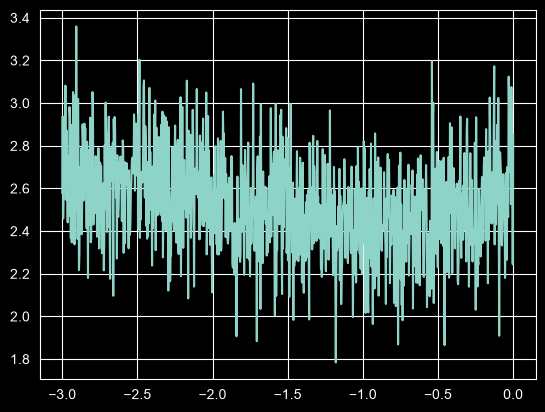

In [159]:
plt.plot(lri,lossi)

In [167]:
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = F.leaky_relu(emb.view(-1,6) @ W1 + b1, negative_slope=0.01)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs,num_samples=1, generator=g).item()
        context = context[1:] + [ix]






        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

зувугдармлматлнл.
вугашангаггинтер.
аюллимен-васн.
ададикийазао.
мулсь.
тях.
вуразем.
вюрагания.
тэг.
веасапенят.
каз.
нрс.
ыуне.
нум.
веберикжазгея.
маентдмел.
шевактат.
ануд.
рурсамэкят.
ния.
